In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, f1_score, recall_score
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 1 = benign, 0 = malignant

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# BLACK-BOX BASELINES — establish the accuracy targets

# GBM baseline
gbm = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
gbm.fit(X_train, y_train)
gbm_preds = gbm.predict(X_test)

# MLP baseline
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train)
mlp_preds = mlp.predict(X_test_scaled)

print("=== BLACK-BOX BASELINES ===")
print(f"GBM    — Accuracy: {accuracy_score(y_test, gbm_preds):.3f}, "
      f"Recall(malignant): {recall_score(y_test, gbm_preds, pos_label=0):.3f}")
print(f"MLP    — Accuracy: {accuracy_score(y_test, mlp_preds):.3f}, "
      f"Recall(malignant): {recall_score(y_test, mlp_preds, pos_label=0):.3f}")
print()

=== BLACK-BOX BASELINES ===
GBM    — Accuracy: 0.956, Recall(malignant): 0.930
MLP    — Accuracy: 0.974, Recall(malignant): 0.953



In [ ]:
# PART 1: THE INTERPRETABILITY BASELINE — GOSDT

from gosdt import ThresholdGuessBinarizer, GOSDTClassifier

GBDT_N_EST = 40
GBDT_MAX_DEPTH = 1

enc = ThresholdGuessBinarizer(
    n_estimators=GBDT_N_EST,
    max_depth=GBDT_MAX_DEPTH,
    random_state=42,
)
enc.set_output(transform="pandas")
X_train_bin = enc.fit_transform(X_train, y_train)
X_test_bin = enc.transform(X_test)

print(f"Binarized features: {X_train_bin.shape[1]} "
      f"(from {X_train.shape[1]} continuous)")

# --- Step 2: Train GOSDT ---

gosdt_model = GOSDTClassifier(
    regularization=0.01,
    depth_budget=5,
    time_limit=60,
    verbose=False,
)
gosdt_model.fit(X_train_bin, y_train)

gosdt_preds = gosdt_model.predict(X_test_bin)

print("\n=== GOSDT (Interpretability Baseline) ===")
print(f"Accuracy:          {accuracy_score(y_test, gosdt_preds):.3f}")
print(f"Recall(malignant): {recall_score(y_test, gosdt_preds, pos_label=0):.3f}")

# --- Inspect the learned tree ---
print("\nOptimal Sparse Tree:")
try:
    print(gosdt_model.trees_[0])
except (AttributeError, IndexError):
    print(gosdt_model)

# how does GOSDT compare to the black-box baselines? ---
gosdt_acc = accuracy_score(y_test, gosdt_preds)
gap_gbm = accuracy_score(y_test, gbm_preds) - gosdt_acc
gap_mlp = accuracy_score(y_test, mlp_preds) - gosdt_acc

print(f"\nAccuracy gap (GBM - GOSDT): {gap_gbm:+.3f}")
print(f"Accuracy gap (MLP - GOSDT): {gap_mlp:+.3f}")
print( "  If these gaps are small (<2-3%), simpler symbolic methods "
       "may suffice.")
print( "  If the gaps are large (>5%), post-hoc extraction in Part 2 "
       "is motivated.")



Binarized features: 24 (from 30 continuous)

=== GOSDT (Interpretability Baseline) ===
Accuracy:          0.956
Recall(malignant): 0.930

Optimal Sparse Tree:
<class 'gosdt._tree.Tree'>: { feature: 14 [ left child: { feature: 1 [ left child: { prediction: 1, loss: 0.017582418397068977 }, right child: { feature: 6 [ left child: { feature: 21 [ left child: { prediction: 1, loss: 0.002197802299633622 }, right child: { prediction: 0, loss: 0.0 }] }, right child: { prediction: 0, loss: 0.0 }] }] }, right child: { prediction: 0, loss: 0.00659340713173151 }] }, Index(['mean texture <= 19.964999198913574',
       'mean concave points <= 0.05127999931573868',
       'area error <= 31.28499984741211', 'worst radius <= 16.795000076293945',
       'worst texture <= 23.02500057220459',
       'worst texture <= 23.34999942779541',
       'worst texture <= 27.52999973297119',
       'worst texture <= 29.484999656677246',
       'worst perimeter <= 101.54999923706055',
       'worst perimeter <= 114.4

c:\Users\liamt\Documents\GitHub\NSAI\corels-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
import time
import pandas as pd
import matplotlib.pyplot as plt

def count_leaves(clf):
    """Best-effort leaf count across GOSDT versions."""
    if hasattr(clf, 'trees_') and clf.trees_:
        tree = clf.trees_[0]
        for attr in ('n_leaves', 'leaves', 'num_leaves'):
            if hasattr(tree, attr):
                v = getattr(tree, attr)
                return v() if callable(v) else v
        return str(tree).count('prediction:')
    return None

reg_grid = [0.1, 0.05, 0.02, 0.01, 0.005, 0.002]   # larger λ → simpler tree
depth_grid = [3, 4, 5, 6]

sweep = []
for reg in reg_grid:
    for depth in depth_grid:
        t0 = time.perf_counter()
        m = GOSDTClassifier(
            regularization=reg,
            depth_budget=depth,
            time_limit=120,
            verbose=False,
        )
        try:
            m.fit(X_train_bin, y_train)
            preds = m.predict(X_test_bin)
            sweep.append({
                'reg': reg,
                'depth': depth,
                'n_leaves': count_leaves(m),
                'train_s': time.perf_counter() - t0,
                'test_acc': accuracy_score(y_test, preds),
                'test_recall_mal': recall_score(y_test, preds, pos_label=0),
            })
        except Exception as e:
            print(f"Failed at reg={reg}, depth={depth}: {e}")

sweep_df = pd.DataFrame(sweep).sort_values(['n_leaves', 'test_acc'])
print(sweep_df.to_string(index=False))

c:\Users\liamt\Documents\GitHub\NSAI\corels-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\liamt\Documents\GitHub\NSAI\corels-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\liamt\Documents\GitHub\NSAI\corels-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\liamt\Documents\GitHub\NSAI\corels-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\liamt\Documents\GitHub\NSAI\corels-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: '

[WARNING] A regularization was chosen that is less than 1 / (# of samples) = 0.002197802197802198. This may lead to a longer training time if not adjusted.
[WARNING] Regularization increased to 1 / (# of samples) = 0.002197802197802198. If you would like to continue with your chosen regularization (0.002), please set allow_small_reg=True.
[WARNING] A regularization was chosen that is less than 1 / (# of samples) = 0.002197802197802198. This may lead to a longer training time if not adjusted.
[WARNING] Regularization increased to 1 / (# of samples) = 0.002197802197802198. If you would like to continue with your chosen regularization (0.002), please set allow_small_reg=True.


c:\Users\liamt\Documents\GitHub\NSAI\corels-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[WARNING] A regularization was chosen that is less than 1 / (# of samples) = 0.002197802197802198. This may lead to a longer training time if not adjusted.
[WARNING] Regularization increased to 1 / (# of samples) = 0.002197802197802198. If you would like to continue with your chosen regularization (0.002), please set allow_small_reg=True.


c:\Users\liamt\Documents\GitHub\NSAI\corels-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[WARNING] A regularization was chosen that is less than 1 / (# of samples) = 0.002197802197802198. This may lead to a longer training time if not adjusted.
[WARNING] Regularization increased to 1 / (# of samples) = 0.002197802197802198. If you would like to continue with your chosen regularization (0.002), please set allow_small_reg=True.
  reg  depth  n_leaves  train_s  test_acc  test_recall_mal
0.100      3         2 0.002656  0.894737         0.906977
0.100      4         2 0.002237  0.894737         0.906977
0.100      5         2 0.002050  0.894737         0.906977
0.100      6         2 0.001942  0.894737         0.906977
0.050      3         2 0.002079  0.894737         0.906977
0.050      4         2 0.002058  0.894737         0.906977
0.050      5         2 0.002055  0.894737         0.906977
0.050      6         2 0.002168  0.894737         0.906977
0.020      3         3 0.008618  0.947368         0.930233
0.020      4         3 0.010075  0.947368         0.930233
0.020     

c:\Users\liamt\Documents\GitHub\NSAI\corels-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


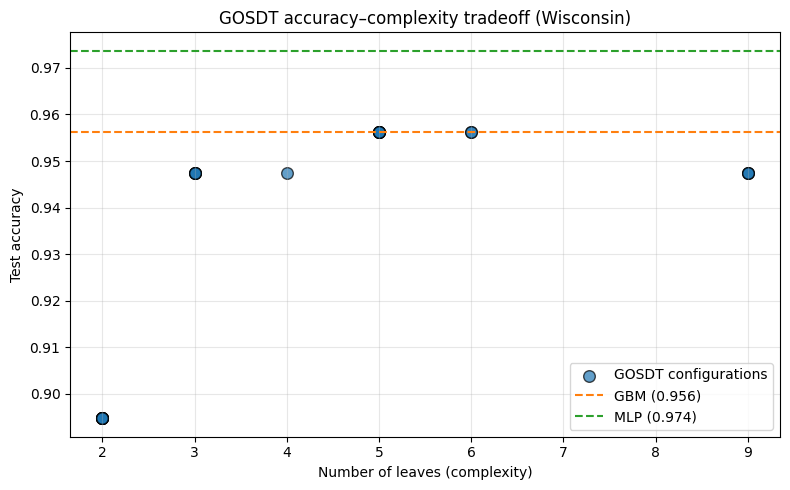

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sweep_df['n_leaves'], sweep_df['test_acc'],
           s=70, alpha=0.7, edgecolor='k', label='GOSDT configurations')

# Reference baselines
gbm_acc = accuracy_score(y_test, gbm_preds)
mlp_acc = accuracy_score(y_test, mlp_preds)
ax.axhline(gbm_acc, ls='--', c='tab:orange', label=f'GBM ({gbm_acc:.3f})')
ax.axhline(mlp_acc, ls='--', c='tab:green',  label=f'MLP ({mlp_acc:.3f})')

ax.set_xlabel('Number of leaves (complexity)')
ax.set_ylabel('Test accuracy')
ax.set_title('GOSDT accuracy–complexity tradeoff (Wisconsin)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import re
from collections import Counter

def features_actually_used(tree, columns):
    tree_repr = str(tree)
    tree_only = tree_repr.split('Index(')[0]
    indices = [int(i) for i in re.findall(r'feature:\s*(\d+)', tree_only)]
    return [columns[i] for i in indices]

stab = []
for seed in range(10):
    Xtr, Xte, ytr_s, yte_s = train_test_split(X, y, test_size=0.2, random_state=seed)
    enc_s = ThresholdGuessBinarizer(n_estimators=40, max_depth=1, random_state=seed)
    enc_s.set_output(transform="pandas")
    Xtr_bin_s = enc_s.fit_transform(Xtr, ytr_s)
    Xte_bin_s = enc_s.transform(Xte)

    m = GOSDTClassifier(regularization=0.01, depth_budget=5,
                       time_limit=120, verbose=False)
    m.fit(Xtr_bin_s, ytr_s)
    p = m.predict(Xte_bin_s)

    used = features_actually_used(m.trees_[0], list(Xtr_bin_s.columns))
    stab.append({
        'seed': seed,
        'acc': accuracy_score(yte_s, p),
        'n_leaves': count_leaves(m),
        'features': used,
    })

stab_df = pd.DataFrame(stab)
print(f"Test accuracy: {stab_df['acc'].mean():.3f} ± {stab_df['acc'].std():.3f}")
print(f"Leaves:        {stab_df['n_leaves'].mean():.1f} ± {stab_df['n_leaves'].std():.1f}")

feat_counts = Counter()
for fs in stab_df['features']:
    for f in fs:
        feat_counts[f.split(' <=')[0]] += 1

total_splits = sum(feat_counts.values())
print(f"\nFeature usage across {len(stab_df)} runs ({total_splits} total splits):")
for feat, n in feat_counts.most_common():
    print(f"  {n:>2}  {feat}")

c:\Users\liamt\Documents\GitHub\NSAI\corels-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\liamt\Documents\GitHub\NSAI\corels-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\liamt\Documents\GitHub\NSAI\corels-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\liamt\Documents\GitHub\NSAI\corels-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\liamt\Documents\GitHub\NSAI\corels-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: '

Test accuracy: 0.932 ± 0.018
Leaves:        3.2 ± 0.4

Feature usage across 10 runs (22 total splits):
   9  worst area
   9  worst concave points
   2  worst texture
   1  worst perimeter
   1  mean concave points


c:\Users\liamt\Documents\GitHub\NSAI\corels-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [9]:
for n_est in [20, 40, 80, 160]:
    enc_t = ThresholdGuessBinarizer(n_estimators=n_est, max_depth=1, random_state=42)
    enc_t.set_output(transform="pandas")
    Xtr_b = enc_t.fit_transform(X_train, y_train)
    Xte_b = enc_t.transform(X_test)

    m = GOSDTClassifier(regularization=0.01, depth_budget=5,
                       time_limit=120, verbose=False)
    m.fit(Xtr_b, y_train)              # <-- y_train, not ytr
    p = m.predict(Xte_b)
    print(f"n_est={n_est:>3}: {Xtr_b.shape[1]:>3} bin features, "
          f"acc={accuracy_score(y_test, p):.3f}, "
          f"leaves={count_leaves(m)}")

c:\Users\liamt\Documents\GitHub\NSAI\corels-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


n_est= 20:  11 bin features, acc=0.947, leaves=3


c:\Users\liamt\Documents\GitHub\NSAI\corels-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


n_est= 40:  24 bin features, acc=0.956, leaves=5


c:\Users\liamt\Documents\GitHub\NSAI\corels-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


n_est= 80:  22 bin features, acc=0.956, leaves=5
n_est=160:  39 bin features, acc=0.947, leaves=4


c:\Users\liamt\Documents\GitHub\NSAI\corels-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [10]:
# ============================================================
# ADDITIONAL INHERENTLY INTERPRETABLE METHODS
# ============================================================

# --- RIPPER (direct rule learning — no tree intermediate) ---
from wittgenstein import RIPPER

ripper = RIPPER(k=2)
ripper.fit(X_train, y_train, class_feat='target')

ripper_preds = ripper.predict(X_test)
print("=== RIPPER ===")
print(f"Accuracy: {accuracy_score(y_test, ripper_preds):.3f}")
print(f"Recall(malignant): {recall_score(y_test, ripper_preds, pos_label=0):.3f}")
print(f"Number of rules: {len(ripper.ruleset_)}")
print("Rules learned:")
print(ripper.ruleset_)
print()

=== RIPPER ===
Accuracy: 0.947
Recall(malignant): 0.953
Number of rules: 15
Rules learned:
[[meanconcavepoints=0.011-0.018] V [meanconcavepoints=0.018-0.023] V [meanconcavepoints=0.023-0.028^worstsymmetry=<0.23] V [meanconcavepoints=<0.011] V [meanconcavepoints=0.033-0.047] V [meanconcavepoints=0.028-0.033] V [meanconcavepoints=0.023-0.028^worstconcavepoints=0.07-0.084] V [meanconcavepoints=0.023-0.028] V [meanconcavepoints=0.047-0.062^smoothnesserror=>0.01] V [meantexture=<14.13] V [meanconcavepoints=0.047-0.062^meanarea=445.44-497.4] V [meanconcavepoints=0.047-0.062^meanfractaldimension=0.057-0.059] V [worstarea=686.6-784.04^meantexture=18.68-19.82] V [worstradius=<11.19] V [worsttexture=17.7-20.05^meanarea=610.22-692.86]]



In [ ]:
# --- RuleFit (rules extracted from tree ensemble + L1 selection) ---
from imodels import RuleFitClassifier

rulefit = RuleFitClassifier(max_rules=20, random_state=42)
rulefit.fit(X_train.values, y_train, feature_names=list(data.feature_names))

rulefit_preds = rulefit.predict(X_test.values)
print("=== RuleFit ===")
print(f"Accuracy: {accuracy_score(y_test, rulefit_preds):.3f}")
print(f"Recall(malignant): {recall_score(y_test, rulefit_preds, pos_label=0):.3f}")

try:
    rules_df = rulefit._get_rules()
except AttributeError:
    rules_df = rulefit.visualize()

active = rules_df[rules_df['coef'].abs() > 0.01].copy()
active = active.sort_values('coef', key=lambda s: s.abs(), ascending=False)

print(f"Total rules generated:  {len(rules_df)}")
print(f"Active rules (|coef|>0.01): {len(active)}")
print(f"\nTop 10 active rules by |coefficient|:")
print(active.head(10).to_string(index=False))

=== RuleFit ===
Accuracy: 0.956
Recall(malignant): 0.930
Total rules generated:  50
Active rules (|coef|>0.01): 20

Top 10 active rules by |coefficient|:
                                                                                                                     rule type      coef  support  importance
                                       area error <= 42.95 and worst area <= 957.45001 and worst concave points <= 0.1419 rule  1.336289 0.602198    0.654039
concavity error <= 0.13565 and worst texture > 18.355 and worst concave points > 0.11135 and mean concave points > 0.0508 rule -1.157389 0.331868    0.544996
                                 mean texture <= 21.165 and worst perimeter <= 114.65 and worst concave points <= 0.18075 rule  1.100690 0.534066    0.549066
                                                                      worst radius > 16.815 and worst concavity > 0.21805 rule -0.718860 0.314286    0.333717
                                                        

In [ ]:
from imodels import BayesianRuleListClassifier

brl = BayesianRuleListClassifier(max_iter=10000, listlengthprior=3)
try:
    brl.fit(X_train_bin.values, y_train,
            feature_names=list(X_train_bin.columns))
    brl_preds = brl.predict(X_test_bin.values)
    print("=== Bayesian Rule Lists ===")
    print(f"Accuracy:          {accuracy_score(y_test, brl_preds):.3f}")
    print(f"Recall(malignant): {recall_score(y_test, brl_preds, pos_label=0):.3f}")
    print()
    print(brl)
except Exception as e:
    print(f"BRL failed: {e}")

c:\Users\liamt\Documents\GitHub\NSAI\corels-env\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


=== Bayesian Rule Lists ===
Accuracy:          0.956
Recall(malignant): 0.907

Trained RuleListClassifier 
IF mean texture <= 19.964999198913574 > 0.5 and worst concavity <= 0.21640000492334366 > 0.5 THEN probability of class 1: 98.8% (96.8%-99.9%)
ELSE IF mean concave points <= 0.05127999931573868 > 0.5 and worst radius <= 16.795000076293945 > 0.5 THEN probability of class 1: 95.3% (90.6%-98.5%)
ELSE IF worst area <= 953.7000122070312 > 0.5 and worst texture <= 23.02500057220459 > 0.5 THEN probability of class 1: 85.7% (64.0%-98.1%)
ELSE IF worst area <= 750.0499877929688 > 0.5 and worst concave points <= 0.15720000118017197 > 0.5 THEN probability of class 1: 66.7% (34.9%-91.5%)
ELSE probability of class 1: 0.6% (0.0%-2.3%)



In [ ]:
# PART 2: POST-HOC RULE EXTRACTION FROM BLACK-BOX MODELS
# "Can we decompile the GBM and MLP into auditable rules?"

# --- Extract from GBM via mimic tree ---
gbm_hard_labels = gbm.predict(X_train)

mimic_tree_gbm = DecisionTreeClassifier(max_depth=4, random_state=42)
mimic_tree_gbm.fit(X_train, gbm_hard_labels)  # learn to reproduce GBM, not true labels
mimic_gbm_preds = mimic_tree_gbm.predict(X_test)

fidelity_gbm = accuracy_score(gbm_preds, mimic_gbm_preds)
accuracy_gbm_mimic = accuracy_score(y_test, mimic_gbm_preds)

print("=== Mimic Tree — extracted from GBM ===")
print(f"Fidelity to GBM: {fidelity_gbm:.3f}")
print(f"True accuracy: {accuracy_gbm_mimic:.3f}")
print(f"Recall(malignant): {recall_score(y_test, mimic_gbm_preds, pos_label=0):.3f}")
print(f"GBM accuracy: {accuracy_score(y_test, gbm_preds):.3f}")
print(f"\nExtracted rules from GBM:")
print(export_text(mimic_tree_gbm, feature_names=list(data.feature_names)))

mlp_hard_labels = mlp.predict(X_train_scaled)

mimic_tree_mlp = DecisionTreeClassifier(max_depth=4, random_state=42)
mimic_tree_mlp.fit(X_train, mlp_hard_labels)
mimic_mlp_preds = mimic_tree_mlp.predict(X_test)

fidelity_mlp = accuracy_score(mlp_preds, mimic_mlp_preds)
accuracy_mlp_mimic = accuracy_score(y_test, mimic_mlp_preds)

print(f"\n=== Mimic Tree — extracted from MLP ===")
print(f"Fidelity to MLP: {fidelity_mlp:.3f}")
print(f"True accuracy: {accuracy_mlp_mimic:.3f}")
print(f"Recall(malignant): {recall_score(y_test, mimic_mlp_preds, pos_label=0):.3f}")
print(f"MLP accuracy: {accuracy_score(y_test, mlp_preds):.3f}")
print(f"\nExtracted rules from MLP:")
print(export_text(mimic_tree_mlp, feature_names=list(data.feature_names)))

=== Mimic Tree — extracted from GBM ===
Fidelity to GBM: 0.991
True accuracy: 0.947
Recall(malignant): 0.930
GBM accuracy: 0.956

Extracted rules from GBM:
|--- mean concave points <= 0.05
|   |--- worst radius <= 16.83
|   |   |--- area error <= 48.70
|   |   |   |--- worst smoothness <= 0.18
|   |   |   |   |--- class: 1
|   |   |   |--- worst smoothness >  0.18
|   |   |   |   |--- class: 0
|   |   |--- area error >  48.70
|   |   |   |--- texture error <= 1.93
|   |   |   |   |--- class: 1
|   |   |   |--- texture error >  1.93
|   |   |   |   |--- class: 0
|   |--- worst radius >  16.83
|   |   |--- worst texture <= 19.91
|   |   |   |--- class: 1
|   |   |--- worst texture >  19.91
|   |   |   |--- concave points error <= 0.01
|   |   |   |   |--- class: 0
|   |   |   |--- concave points error >  0.01
|   |   |   |   |--- class: 1
|--- mean concave points >  0.05
|   |--- worst concave points <= 0.15
|   |   |--- worst perimeter <= 115.25
|   |   |   |--- mean texture <= 21.06
| 